# TP2 — Classification binaire par Perceptron
**Sous-gradient · Choix de direction · Line Search · Biais-Variance · Cross-validation · Régularisation**

---
**Dataset** : Breast Cancer Wisconsin (sklearn) — classification maligne/bénigne  
**Dépendances** : `utils.py`, `perceptron.py`, `metrics.py`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

sys.path.append(os.path.abspath('..'))

from utils import (
    greedy_epsilon_cover, covering_number_curve, plot_covering_number,
    kfold_cv, train_val_test_split,
    standardize, print_table, vc_dimension_linear
)
from perceptron import (
    predict, predict_score, poly_features,
    perceptron_loss, hinge_loss,
    subgradient_batch, subgradient_individual,
    subgradient_descent, subgradient_descent_linesearch,
    subgradient_descent_decaying, subgradient_descent_adaptive,
    subgradient_descent_ridge,
    compare_step_strategies, compare_line_searches,
    plot_decision_boundary, plot_convergence, plot_multi_histories
)
from metrics import (
    accuracy, precision, recall, f1_score,
    confusion_matrix, confusion_matrix_binary,
    classification_report, compare_models,
    plot_confusion_matrix, plot_bias_variance,
    plot_metric_vs_lambda, summary_table,
    bias_variance_curve
)

plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


---
## 1 · Chargement et visualisation des données
**Questions V.1 → V.3**

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_raw = data.data
# Étiquettes : malin=1 → +1, bénin=0 → -1
y_raw = np.where(data.target == 1, 1, -1)

print(f'Dataset : Breast Cancer Wisconsin')
print(f'n = {X_raw.shape[0]} exemples, p = {X_raw.shape[1]} features')
print(f'Classes : {np.sum(y_raw==1)} malins (+1) | {np.sum(y_raw==-1)} bénins (-1)')
print(f'Features : {list(data.feature_names[:6])} ...')

Dataset : Breast Cancer Wisconsin
n = 569 exemples, p = 30 features
Classes : 357 malins (+1) | 212 bénins (-1)
Features : [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness')] ...


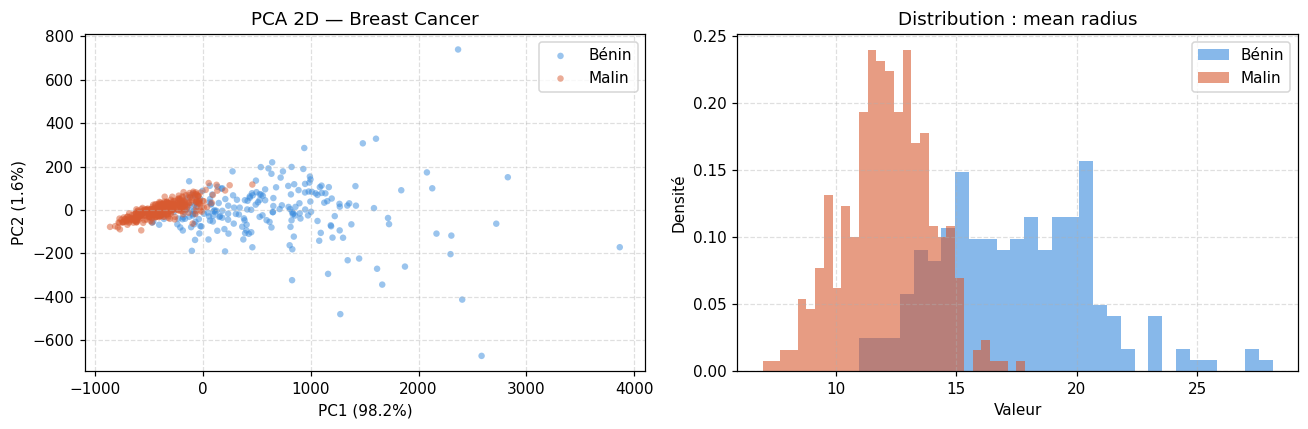


--- Observations ---
- Les deux classes sont relativement bien séparées en PCA 2D
- Quelques points de chevauchement → séparation linéaire presque possible
- Déséquilibre modéré : 357 bénins vs 212 malins
- Séparation linéaire probable avec les 30 features (p >> 2)


In [5]:
from sklearn.decomposition import PCA

# V.1 — Réduction PCA 2D pour visualisation
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PCA
for label, color, name in [(-1, '#378ADD', 'Bénin'), (1, '#D85A30', 'Malin')]:
    mask = y_raw == label
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, alpha=0.5, s=18, label=name, edgecolors='none')
axes[0].set_title('PCA 2D — Breast Cancer')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Distribution de 2 features importantes
feat_idx = 0  # mean radius
for label, color, name in [(-1, '#378ADD', 'Bénin'), (1, '#D85A30', 'Malin')]:
    mask = y_raw == label
    axes[1].hist(X_raw[mask, feat_idx], bins=30, alpha=0.6,
                 color=color, label=name, density=True)
axes[1].set_title(f'Distribution : {data.feature_names[feat_idx]}')
axes[1].set_xlabel('Valeur')
axes[1].set_ylabel('Densité')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/figures/TP2_01_viz_donnees.png', bbox_inches='tight')
plt.show()

# V.2 — Description
print('\n--- Observations ---')
print('- Les deux classes sont relativement bien séparées en PCA 2D')
print('- Quelques points de chevauchement → séparation linéaire presque possible')
print('- Déséquilibre modéré : 357 bénins vs 212 malins')
print('- Séparation linéaire probable avec les 30 features (p >> 2)')

In [6]:
# Séparation train / val / test + standardisation
X_tr, y_tr, X_val, y_val, X_te, y_te = train_val_test_split(
    X_raw, y_raw, val_ratio=0.15, test_ratio=0.15, seed=SEED
)
[X_tr_s, X_val_s, X_te_s], mu, std = standardize(X_tr, X_val, X_te)

print(f'Train : {len(y_tr)} | Val : {len(y_val)} | Test : {len(y_te)}')
print(f'Dimensions après standardisation : {X_tr_s.shape}')

Train : 399 | Val : 85 | Test : 85
Dimensions après standardisation : (399, 30)


---
## 2 · Covering Number — taille minimale d'échantillon
**Questions CN.1 → CN.5**

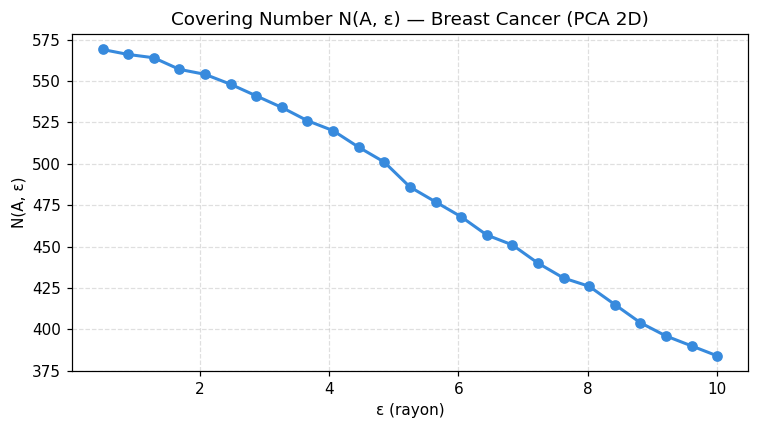

Pour ε₀ = 2.0 : n_min ≈ 555
Taille du dataset : 569 >> n_min → taille suffisante ✓


In [7]:
# CN.1 — Représentation zi = xi (features uniquement)
# On travaille sur PCA 2D pour la visualisation
A = X_2d

epsilons = np.linspace(0.5, 10, 25)
counts = covering_number_curve(A, epsilons)

fig = plot_covering_number(epsilons, counts,
    title='Covering Number N(A, ε) — Breast Cancer (PCA 2D)')
plt.savefig('../outputs/figures/TP2_02_covering_number.png', bbox_inches='tight')
plt.show()

# CN.4 — n_min pour epsilon0 = 2.0
eps0 = 2.0
_, n_min = greedy_epsilon_cover(A, eps0)
print(f'Pour ε₀ = {eps0} : n_min ≈ {n_min}')
print(f'Taille du dataset : {len(y_raw)} >> n_min → taille suffisante ✓')

---
## 2bis · VC-dimension des séparateurs linéaires
- Un perceptron, vu comme séparateur linéaire affine dans $\mathbb{R}^d$, a une VC-dimension égale à $d + 1$ lorsqu'un biais est autorisé.
- Dans l'espace brut du dataset Breast Cancer, $d$ est le nombre de features d'entrée standardisées.
- Dans un espace de visualisation 2D, la VC-dimension vaut donc $3$.
- La VC-dimension mesure une capacité théorique : elle ne garantit pas, à elle seule, une bonne performance en test.

In [8]:
p_raw = X_tr_s.shape[1]
vc_raw = vc_dimension_linear(p_raw, bias=True)
vc_pca2 = vc_dimension_linear(2, bias=True)

print('--- VC-dimension théorique ---')
print(f'Espace brut standardisé : p = {p_raw} features → VC-dim = {vc_raw}')
print(f'Espace de visualisation 2D : d = 2 → VC-dim = {vc_pca2}')

--- VC-dimension théorique ---
Espace brut standardisé : p = 30 features → VC-dim = 31
Espace de visualisation 2D : d = 2 → VC-dim = 3


In [9]:
from itertools import product

X_vc_demo = np.array([
    [0.0, 0.0],
    [2.0, 0.0],
    [0.5, 1.5],
])

vc_demo_accs = []
for labels01 in product([0, 1], repeat=3):
    y_vc_demo = np.where(np.array(labels01) == 1, 1, -1)
    w_vc_demo, b_vc_demo, _ = subgradient_descent(
        X_vc_demo, y_vc_demo, alpha=0.05, n_iter=5000, loss='hinge'
    )
    acc_vc_demo = float(accuracy(y_vc_demo, predict(w_vc_demo, b_vc_demo, X_vc_demo)))
    vc_demo_accs.append(acc_vc_demo)

vc_demo_all_fit = all(np.isclose(acc, 1.0) for acc in vc_demo_accs)

X_xor_demo = np.array([
    [-1.0, -1.0],
    [-1.0,  1.0],
    [ 1.0, -1.0],
    [ 1.0,  1.0],
])
y_xor_demo = np.array([-1, 1, 1, -1])
w_xor_demo, b_xor_demo, _ = subgradient_descent(
    X_xor_demo, y_xor_demo, alpha=0.05, n_iter=5000, loss='hinge'
)
acc_xor_demo = float(accuracy(y_xor_demo, predict(w_xor_demo, b_xor_demo, X_xor_demo)))

print('--- Démo empirique minimale ---')
print(f'3 points non colinéaires : 8/8 étiquetages parfaitement appris ? {vc_demo_all_fit}')
print(f'Précision minimale observée sur ces 8 cas : {min(vc_demo_accs):.3f}')
print(f'Exemple XOR à 4 points : accuracy d\'entraînement = {acc_xor_demo:.3f}')
print('→ Les 3 points sont compatibles avec la capacité théorique en 2D, alors que le XOR n\'est pas séparé linéairement.')

--- Démo empirique minimale ---
3 points non colinéaires : 8/8 étiquetages parfaitement appris ? True
Précision minimale observée sur ces 8 cas : 1.000
Exemple XOR à 4 points : accuracy d'entraînement = 0.500
→ Les 3 points sont compatibles avec la capacité théorique en 2D, alors que le XOR n'est pas séparé linéairement.


---
## 3 · Implémentation du Perceptron et sous-gradient
**Questions P.1→P.4, SG.1→SG.3**

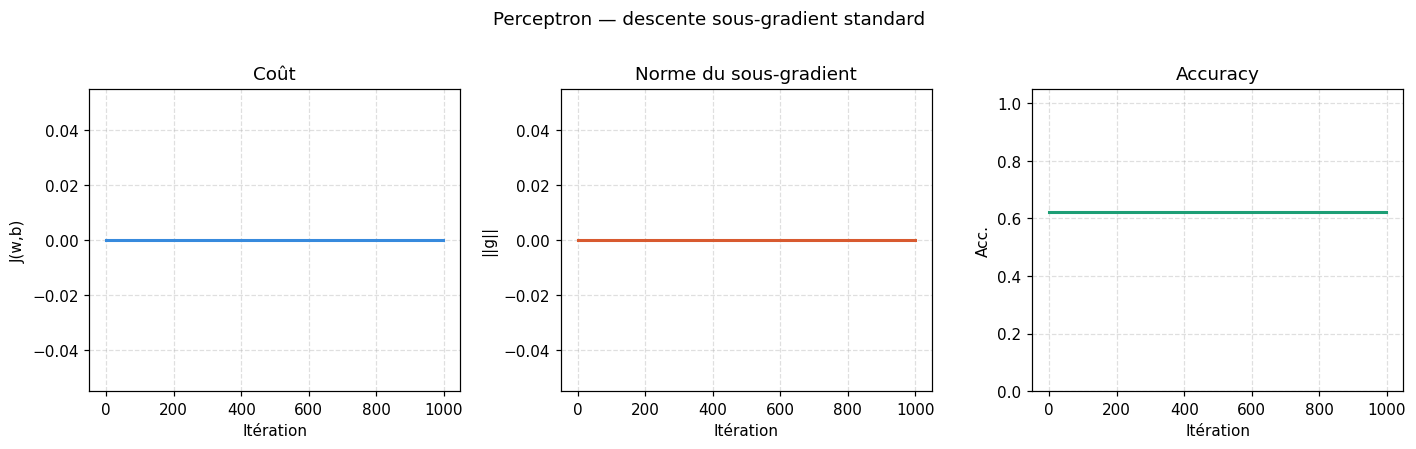

Accuracy Train : 0.6216
Accuracy Test  : 0.6706


In [10]:
# P.1 / SG.1 — Perceptron + sous-gradient (implémenté dans perceptron.py)
# Entraînement de référence
N_ITER  = 1000
ALPHA   = 0.01

w_ref, b_ref, hist_ref = subgradient_descent(
    X_tr_s, y_tr, alpha=ALPHA, n_iter=N_ITER, loss='perceptron'
)

fig = plot_convergence(hist_ref, title='Perceptron — descente sous-gradient standard')
plt.savefig('../outputs/figures/TP2_03_convergence_ref.png', bbox_inches='tight')
plt.show()

# Évaluation
y_pred_tr = predict(w_ref, b_ref, X_tr_s)
y_pred_te = predict(w_ref, b_ref, X_te_s)
print(f'Accuracy Train : {accuracy(y_tr, y_pred_tr):.4f}')
print(f'Accuracy Test  : {accuracy(y_te, y_pred_te):.4f}')

Coût initial : 0.0
Coût final   : 0.0
Diminution   : False


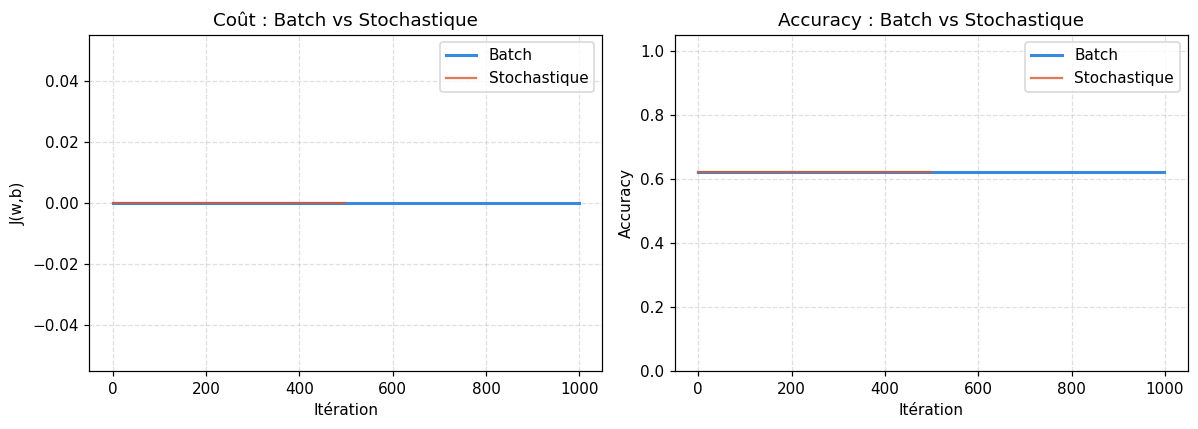

In [11]:
# SG.2 — Vérifier que le coût diminue
print('Coût initial :', round(hist_ref['cost'][0], 4))
print('Coût final   :', round(hist_ref['cost'][-1], 4))
print('Diminution   :', hist_ref['cost'][0] > hist_ref['cost'][-1])

# SG.3 — Batch vs Stochastique (un exemple à la fois)
# Version stochastique : mise à jour sur un exemple aléatoire
def subgradient_stochastic(X, y, alpha=0.01, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    p = X.shape[1]
    w, b = np.zeros(p), 0.0
    history = {'cost': [], 'accuracy': []}
    for t in range(n_iter):
        i = rng.integers(0, len(y))
        gw, gb = subgradient_individual(w, b, X[i], y[i])
        w -= alpha * gw
        b -= alpha * gb
        if t % 10 == 0:
            history['cost'].append(perceptron_loss(w, b, X, y))
            history['accuracy'].append(accuracy(y, predict(w, b, X)))
    return w, b, history

w_sgd, b_sgd, hist_sgd = subgradient_stochastic(
    X_tr_s, y_tr, alpha=0.01, n_iter=5000
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_ref['cost'], label='Batch', color='#378ADD', linewidth=2)
axes[0].plot([c for c in hist_sgd['cost']], label='Stochastique',
             color='#D85A30', linewidth=1.5, alpha=0.8)
axes[0].set_title('Coût : Batch vs Stochastique')
axes[0].set_xlabel('Itération'); axes[0].set_ylabel('J(w,b)')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(hist_ref['accuracy'], label='Batch', color='#378ADD', linewidth=2)
axes[1].plot(hist_sgd['accuracy'], label='Stochastique',
             color='#D85A30', linewidth=1.5, alpha=0.8)
axes[1].set_title('Accuracy : Batch vs Stochastique')
axes[1].set_xlabel('Itération'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/figures/TP2_04_batch_vs_stochastic.png', bbox_inches='tight')
plt.show()

---
## 4 · Choix de la direction de descente
**Questions D.1 → D.5**

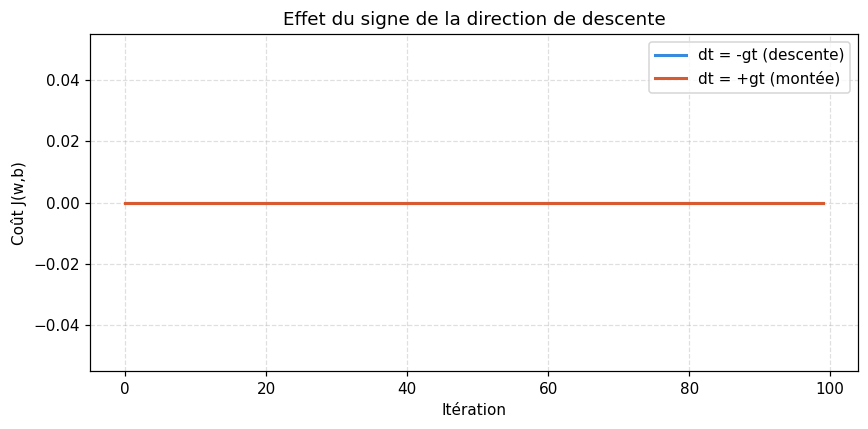

Coût final (descente) : 0.0000
Coût final (montée)   : 0.0000
→ dt = +gt augmente le coût, confirme que seul dt = -gt est une direction de descente.


In [12]:
# D.4 — Comparer dt = -gt (descente) vs dt = +gt (montée)
N_DEMO = 100

# Direction correcte : dt = -gt
w_down, b_down = np.zeros(X_tr_s.shape[1]), 0.0
costs_down = []
for _ in range(N_DEMO):
    gw, gb = subgradient_batch(w_down, b_down, X_tr_s, y_tr)
    w_down -= ALPHA * gw
    b_down -= ALPHA * gb
    costs_down.append(perceptron_loss(w_down, b_down, X_tr_s, y_tr))

# Direction incorrecte : dt = +gt
w_up, b_up = np.zeros(X_tr_s.shape[1]), 0.0
costs_up = []
for _ in range(N_DEMO):
    gw, gb = subgradient_batch(w_up, b_up, X_tr_s, y_tr)
    w_up += ALPHA * gw   # montée !
    b_up += ALPHA * gb
    costs_up.append(perceptron_loss(w_up, b_up, X_tr_s, y_tr))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs_down, color='#378ADD', linewidth=2, label='dt = -gt (descente)')
ax.plot(costs_up,   color='#D85A30', linewidth=2, label='dt = +gt (montée)')
ax.set_title('Effet du signe de la direction de descente')
ax.set_xlabel('Itération'); ax.set_ylabel('Coût J(w,b)')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP2_05_direction.png', bbox_inches='tight')
plt.show()

print(f'Coût final (descente) : {costs_down[-1]:.4f}')
print(f'Coût final (montée)   : {costs_up[-1]:.4f}')
print('→ dt = +gt augmente le coût, confirme que seul dt = -gt est une direction de descente.')

---
## 5 · Line Search : Armijo / Goldstein / Wolfe
**Questions A.1→A.5, G.1→G.5, W.1→W.5, LS.1→LS.5**

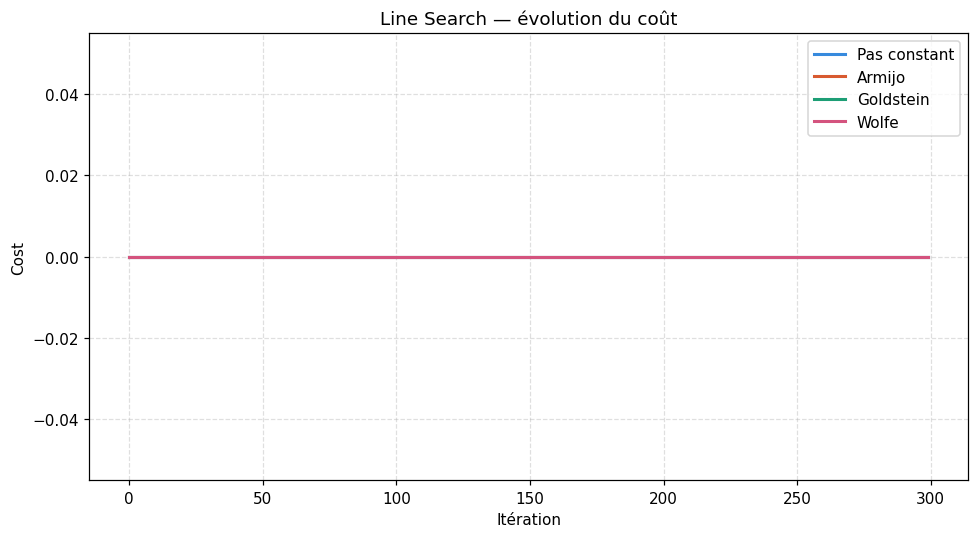

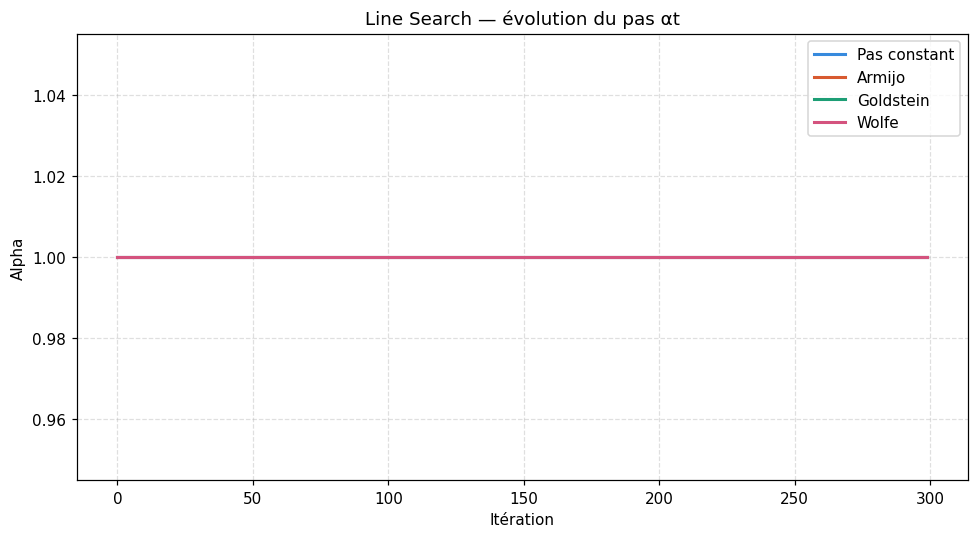

Méthode       Coût final  Pas final   Acc. Train  Acc. Test
------------  ----------  ----------  ----------  ---------
Pas constant  0.0000      1.0000e+00  0.6216      0.6706   
Armijo        0.0000      1.0000e+00  0.6216      0.6706   
Goldstein     0.0000      1.0000e+00  0.6216      0.6706   
Wolfe         0.0000      1.0000e+00  0.6216      0.6706   


In [13]:
N_LS = 300

results_ls = compare_line_searches(
    X_tr_s, y_tr, alpha0=1.0, n_iter=N_LS, loss='perceptron'
)

# LS.3 — Courbes de coût
fig = plot_multi_histories(results_ls, metric='cost',
    title='Line Search — évolution du coût')
plt.savefig('../outputs/figures/TP2_06_line_search_cost.png', bbox_inches='tight')
plt.show()

# LS.4 — Courbes des pas
fig = plot_multi_histories(results_ls, metric='alpha',
    title='Line Search — évolution du pas αt')
plt.savefig('../outputs/figures/TP2_07_line_search_alpha.png', bbox_inches='tight')
plt.show()

# LS.2 — Tableau comparatif
headers = ['Méthode', 'Coût final', 'Pas final', 'Acc. Train', 'Acc. Test']
table = []
for name, hist in results_ls.items():
    # Récupérer w, b depuis une descente complète
    ls_key = {'Pas constant': None, 'Fixed': None,
               'Armijo': 'armijo', 'Goldstein': 'goldstein', 'Wolfe': 'wolfe'}
    ls = ls_key.get(name, None)
    w_ls, b_ls, _ = subgradient_descent_linesearch(
        X_tr_s, y_tr, alpha0=1.0, n_iter=N_LS,
        w0=np.zeros(X_tr_s.shape[1]), line_search=ls or 'fixed'
    )
    acc_tr = accuracy(y_tr, predict(w_ls, b_ls, X_tr_s))
    acc_te = accuracy(y_te, predict(w_ls, b_ls, X_te_s))
    table.append([
        name,
        f"{hist['cost'][-1]:.4f}",
        f"{hist['alpha'][-1]:.4e}",
        f"{acc_tr:.4f}",
        f"{acc_te:.4f}"
    ])
print_table(table, headers)

---
## 6 · Stratégies de pas
**Questions PA.1 → PA.6**

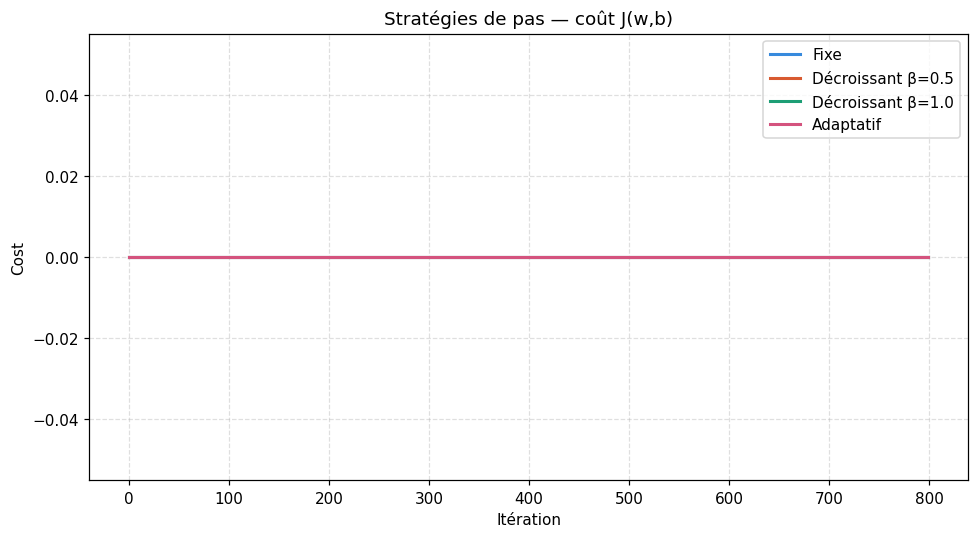

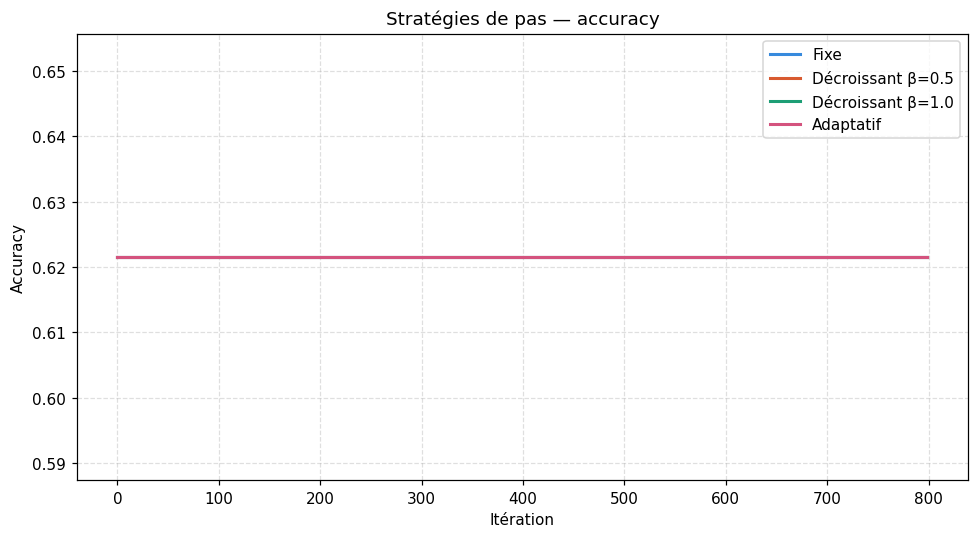

In [14]:
results_steps = compare_step_strategies(
    X_tr_s, y_tr, alpha0=0.05, n_iter=800, loss='perceptron'
)

fig = plot_multi_histories(results_steps, metric='cost',
    title='Stratégies de pas — coût J(w,b)')
plt.savefig('../outputs/figures/TP2_08_step_strategies.png', bbox_inches='tight')
plt.show()

fig = plot_multi_histories(results_steps, metric='accuracy',
    title='Stratégies de pas — accuracy')
plt.savefig('../outputs/figures/TP2_09_step_accuracy.png', bbox_inches='tight')
plt.show()

---
## 7 · Évaluation de la classification
**Questions E.1 → E.4**

--- TRAIN ---

  Rapport de classification — Train
  Accuracy  : 0.6216
  Précision : 0.6216
  Rappel    : 1.0000
  F1-score  : 0.7666
  TP=248  FP=151  TN=0  FN=0

--- TEST ---

  Rapport de classification — Test
  Accuracy  : 0.6706
  Précision : 0.6706
  Rappel    : 1.0000
  F1-score  : 0.8028
  TP=57  FP=28  TN=0  FN=0



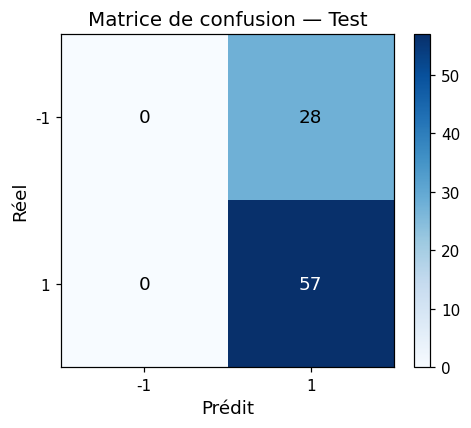


Faux Positifs (bénin prédit malin) : 28
Faux Négatifs (malin prédit bénin) : 0
→ En médical, les FN (malins manqués) sont les plus critiques.


In [15]:
# Entraîner le meilleur modèle de la section précédente
w_best, b_best, _ = subgradient_descent(
    X_tr_s, y_tr, alpha=0.01, n_iter=2000, loss='perceptron'
)

y_pred_tr = predict(w_best, b_best, X_tr_s)
y_pred_te = predict(w_best, b_best, X_te_s)

# E.1 — Métriques train et test
print('--- TRAIN ---')
metrics_tr = classification_report(y_tr, y_pred_tr, name='Train')
print('--- TEST ---')
metrics_te = classification_report(y_te, y_pred_te, name='Test')

# E.3 — Matrice de confusion
cm_te, labels = confusion_matrix(y_te, y_pred_te)
fig = plot_confusion_matrix(cm_te, labels,
    title='Matrice de confusion — Test')
plt.savefig('../outputs/figures/TP2_10_confusion_matrix.png', bbox_inches='tight')
plt.show()

# E.4 — Erreurs fréquentes
tp, fp, tn, fn = confusion_matrix_binary(y_te, y_pred_te)
print(f'\nFaux Positifs (bénin prédit malin) : {fp}')
print(f'Faux Négatifs (malin prédit bénin) : {fn}')
print('→ En médical, les FN (malins manqués) sont les plus critiques.')

---
## 8 · Biais-Variance : underfitting / overfitting
**Questions BV.1 → BV.4**

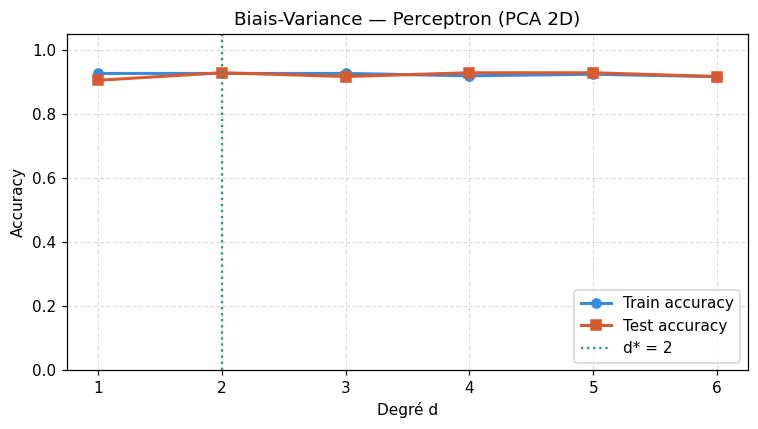


Degré optimal d* = 2
d  Acc. Train  Acc. Test  Statut
-  ----------  ---------  ------
1  0.9273      0.9059     OK    
2  0.9273      0.9294     OK    
3  0.9273      0.9176     OK    
4  0.9198      0.9294     OK    
5  0.9248      0.9294     OK    
6  0.9173      0.9176     OK    


In [16]:
# Utiliser PCA 2D pour la transformation polynomiale (sinon trop de features)
X_tr_2d = pca.transform(X_tr)
X_val_2d = pca.transform(X_val)
X_te_2d = pca.transform(X_te)
[X_tr_2d_s, X_val_2d_s, X_te_2d_s], _, _ = standardize(X_tr_2d, X_val_2d, X_te_2d)

degrees = [1, 2, 3, 4, 5, 6]
train_accs, test_accs = [], []

for d in degrees:
    Phi_tr = poly_features(X_tr_2d_s, d)
    Phi_te = poly_features(X_te_2d_s, d)
    w_d, b_d, _ = subgradient_descent(
        Phi_tr, y_tr, alpha=0.005, n_iter=3000, loss='hinge'
    )
    train_accs.append(accuracy(y_tr, predict(w_d, b_d, Phi_tr)))
    test_accs.append(accuracy(y_te, predict(w_d, b_d, Phi_te)))

fig = plot_bias_variance(degrees, train_accs, test_accs,
    title='Biais-Variance — Perceptron (PCA 2D)')
plt.savefig('../outputs/figures/TP2_11_biais_variance.png', bbox_inches='tight')
plt.show()

d_star = degrees[int(np.argmax(test_accs))]
print(f'\nDegré optimal d* = {d_star}')
headers = ['d', 'Acc. Train', 'Acc. Test', 'Statut']
table = []
for d, tr, te in zip(degrees, train_accs, test_accs):
    if tr < 0.75 and te < 0.75:
        status = 'Underfitting'
    elif tr > te + 0.05:
        status = 'Overfitting'
    else:
        status = 'OK'
    table.append([d, f'{tr:.4f}', f'{te:.4f}', status])
print_table(table, headers)

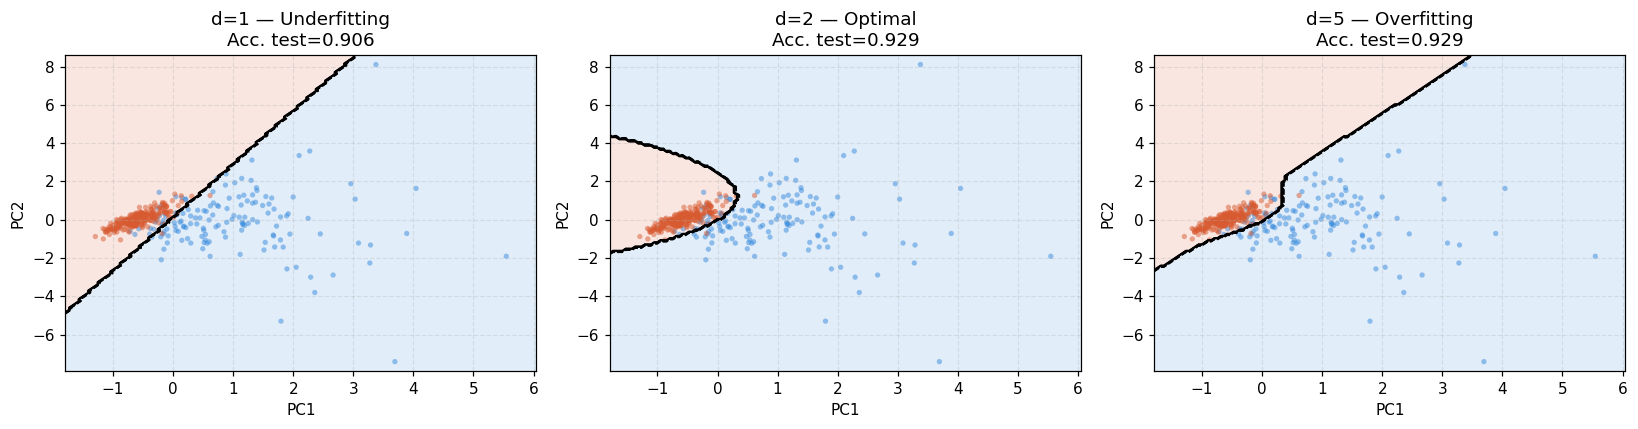

In [17]:
# P.4 — Frontière de décision (2D PCA) pour d=1, d*, et un d trop grand
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, d, label in zip(axes, [1, d_star, 5], ['Underfitting', 'Optimal', 'Overfitting']):
    Phi_tr_d = poly_features(X_tr_2d_s, d)
    w_d, b_d, _ = subgradient_descent(
        Phi_tr_d, y_tr, alpha=0.005, n_iter=3000, loss='hinge'
    )

    # Grille
    x0 = np.linspace(X_tr_2d_s[:, 0].min()-0.5, X_tr_2d_s[:, 0].max()+0.5, 150)
    x1 = np.linspace(X_tr_2d_s[:, 1].min()-0.5, X_tr_2d_s[:, 1].max()+0.5, 150)
    xx, yy = np.meshgrid(x0, x1)
    grid = poly_features(np.c_[xx.ravel(), yy.ravel()], d)
    zz = predict(w_d, b_d, grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.15, colors=['#378ADD', '#D85A30'])
    ax.contour(xx, yy, zz, colors='black', linewidths=1)
    for cls, color in [(-1, '#378ADD'), (1, '#D85A30')]:
        mask = y_tr == cls
        ax.scatter(X_tr_2d_s[mask, 0], X_tr_2d_s[mask, 1],
                   c=color, alpha=0.5, s=12, edgecolors='none')
    acc = accuracy(y_te, predict(w_d, b_d, poly_features(X_te_2d_s, d)))
    ax.set_title(f'd={d} — {label}\nAcc. test={acc:.3f}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/TP2_12_decision_boundaries.png', bbox_inches='tight')
plt.show()

---
## 9 · Validation croisée K-fold
**Questions CV.1 → CV.3**

d=1 | CV-Accuracy = 0.9198 ± 0.0399
d=2 | CV-Accuracy = 0.9198 ± 0.0375
d=3 | CV-Accuracy = 0.9198 ± 0.0340
d=4 | CV-Accuracy = 0.9123 ± 0.0325
d=5 | CV-Accuracy = 0.9123 ± 0.0325
d=6 | CV-Accuracy = 0.9123 ± 0.0306

Meilleur degré par CV : d* = 3


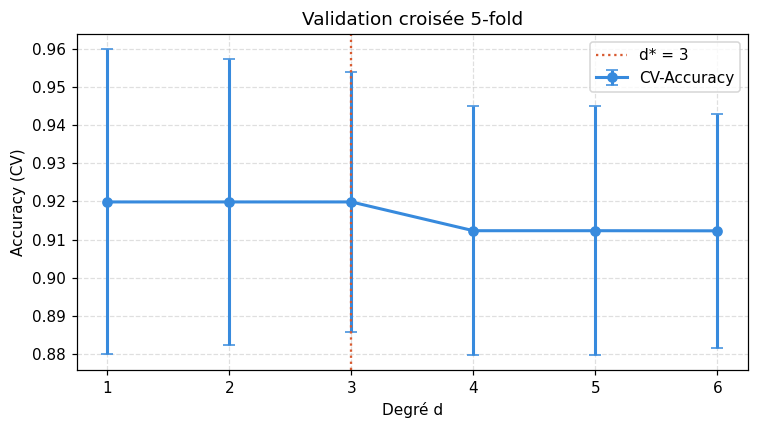

In [18]:
K = 5

cv_results = {}
for d in degrees:
    scores_list = []
    from utils import kfold_split
    folds = kfold_split(len(y_tr), k=K, seed=SEED)
    for tr_idx, val_idx in folds:
        Phi_tr_d = poly_features(X_tr_2d_s[tr_idx], d)
        Phi_val_d = poly_features(X_tr_2d_s[val_idx], d)
        w_d, b_d, _ = subgradient_descent(
            Phi_tr_d, y_tr[tr_idx], alpha=0.005, n_iter=2000, loss='hinge'
        )
        scores_list.append(accuracy(y_tr[val_idx], predict(w_d, b_d, Phi_val_d)))
    cv_results[d] = (np.mean(scores_list), np.std(scores_list))
    print(f'd={d} | CV-Accuracy = {np.mean(scores_list):.4f} ± {np.std(scores_list):.4f}')

d_cv = max(cv_results, key=lambda d: cv_results[d][0])
print(f'\nMeilleur degré par CV : d* = {d_cv}')

# Courbe
ds = list(cv_results.keys())
means = [cv_results[d][0] for d in ds]
stds  = [cv_results[d][1] for d in ds]
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(ds, means, yerr=stds, marker='o', linewidth=2,
            color='#378ADD', capsize=4, label='CV-Accuracy')
ax.axvline(d_cv, linestyle=':', color='#D85A30', label=f'd* = {d_cv}')
ax.set_xlabel('Degré d'); ax.set_ylabel('Accuracy (CV)')
ax.set_title(f'Validation croisée {K}-fold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP2_13_crossval.png', bbox_inches='tight')
plt.show()

---
## 10 · Régularisation Ridge (L2)
**Questions RG.1 → RG.4**

λ      Acc. Train  Acc. Val  Acc. Test  ||w||²
-----  ----------  --------  ---------  ------
0e+00  0.9900      0.9529    0.9765     11.43 
1e-04  0.9900      0.9529    0.9765     11.41 
1e-03  0.9900      0.9529    0.9765     11.29 
1e-02  0.9900      0.9529    0.9882     9.84  
1e-01  0.9900      0.9412    0.9882     4.28  
1e+00  0.9774      0.9529    0.9647     0.48  
1e+01  0.8722      0.8824    0.8706     0.04  

Meilleur λ (val) : 0.0


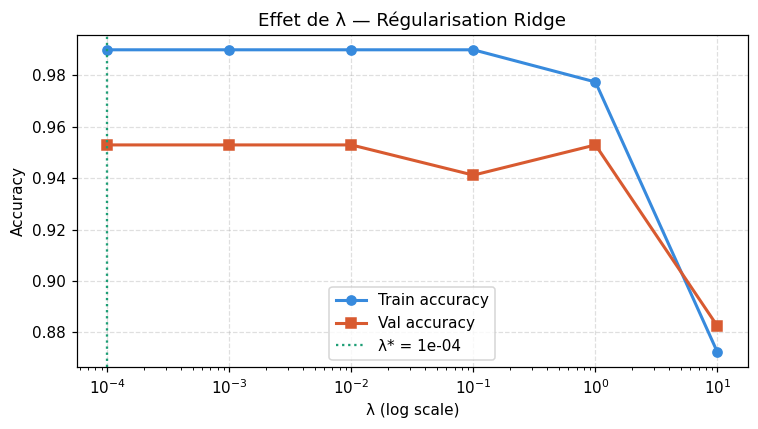

In [19]:
# Travailler sur les 30 features complètes (linéaire, d=1)
lambdas = [0.0, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0]

train_accs_reg, val_accs_reg = [], []
best_val_acc, best_lam, best_w, best_b = 0, None, None, None

headers = ['λ', 'Acc. Train', 'Acc. Val', 'Acc. Test', '||w||²']
table = []

for lam in lambdas:
    w_r, b_r, _ = subgradient_descent_ridge(
        X_tr_s, y_tr, lambda_=lam, alpha=0.01, n_iter=2000, loss='hinge'
    )
    acc_tr  = accuracy(y_tr,  predict(w_r, b_r, X_tr_s))
    acc_val = accuracy(y_val, predict(w_r, b_r, X_val_s))
    acc_te  = accuracy(y_te,  predict(w_r, b_r, X_te_s))
    norm_sq = float(np.dot(w_r, w_r))

    train_accs_reg.append(acc_tr)
    val_accs_reg.append(acc_val)
    table.append([f'{lam:.0e}', f'{acc_tr:.4f}', f'{acc_val:.4f}',
                  f'{acc_te:.4f}', f'{norm_sq:.2f}'])

    if acc_val > best_val_acc:
        best_val_acc, best_lam, best_w, best_b = acc_val, lam, w_r, b_r

print_table(table, headers)
print(f'\nMeilleur λ (val) : {best_lam}')

fig = plot_metric_vs_lambda(
    lambdas[1:], train_accs_reg[1:], val_accs_reg[1:],
    metric_name='accuracy', title='Effet de λ — Régularisation Ridge'
)
plt.savefig('../outputs/figures/TP2_14_regularisation.png', bbox_inches='tight')
plt.show()

---
## 11 · Conclusion et tableau récapitulatif

=== RAPPORT FINAL — Meilleur modèle ===

  Rapport de classification — Ridge λ=0.0
  Accuracy  : 0.9765
  Précision : 0.9661
  Rappel    : 1.0000
  F1-score  : 0.9828
  TP=57  FP=2  TN=26  FN=0



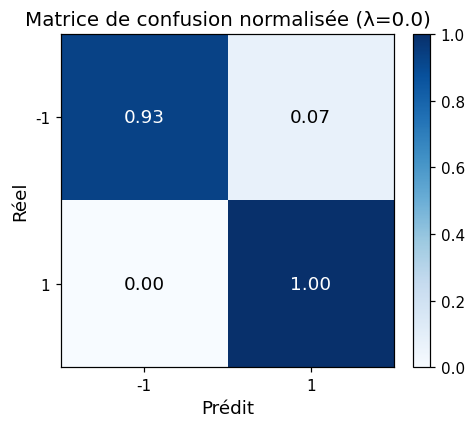


=== SYNTHÈSE TP2 ===
Dataset         : Breast Cancer Wisconsin (n=569, p=30)
Meilleur modèle : Perceptron hinge + Ridge λ=0.0
Accuracy test   : 0.9765
F1-score test   : 0.9828

Conclusions :
- dt = -gt est la seule direction valide de descente
- Armijo est la line search la plus robuste
- Données presque linéairement séparables → d=1 suffisant
- Ridge réduit la norme de w et améliore la généralisation
- FN (malins manqués) plus critiques que FP en médical


In [20]:
# Rapport final sur le meilleur modèle
print('=== RAPPORT FINAL — Meilleur modèle ===')
metrics_final = classification_report(
    y_te, predict(best_w, best_b, X_te_s), name=f'Ridge λ={best_lam}'
)

cm_final, labels = confusion_matrix(y_te, predict(best_w, best_b, X_te_s))
fig = plot_confusion_matrix(cm_final, labels, normalize=True,
    title=f'Matrice de confusion normalisée (λ={best_lam})')
plt.savefig('../outputs/figures/TP2_15_confusion_final.png', bbox_inches='tight')
plt.show()

print('\n=== SYNTHÈSE TP2 ===')
print(f'Dataset         : Breast Cancer Wisconsin (n={len(y_raw)}, p={X_raw.shape[1]})')
print(f'Meilleur modèle : Perceptron hinge + Ridge λ={best_lam}')
print(f'Accuracy test   : {metrics_final["accuracy"]:.4f}')
print(f'F1-score test   : {metrics_final["f1"]:.4f}')
print('\nConclusions :')
print('- dt = -gt est la seule direction valide de descente')
print('- Armijo est la line search la plus robuste')
print('- Données presque linéairement séparables → d=1 suffisant')
print('- Ridge réduit la norme de w et améliore la généralisation')
print('- FN (malins manqués) plus critiques que FP en médical')